## Домашнее задание 5

Вам предстоит провести предобработку текстовых данных на примере открытого HR-датасета.

🗂️ Real or Fake Job Posting Dataset https://www.kaggle.com/datasets/shivamb/real-or-fake-fake-jobposting-prediction

Датасет содержит информацию о вакансиях: тип занятости, требуемый опыт, образование, отрасль, описание вакансии и т.д.

**Цель работы** — очистить и подготовить текстовую часть данных к дальнейшему анализу и моделированию.

`Данные:` колонка description (описание вакансии).

`Что нужно сделать:`

1. Очистка текста (2 балла)

  * Приведите текст к нижнему регистру.
  * Удалите HTML-теги, спецсимволы, цифры, пунктуацию.
  * Удалите стоп-слова

2. Токенизация (2 балла)

  * Разбейте текст на слова (токены).
  * Подсчитайте длину текстов (количество слов).
  * Постройте график распределения длины описаний.

3. Лемматизация или стемминг (2 балла)

  * Примените Лемматизацию или Стемминг
  * Покажите пример до и после обработки.

4. Финальный признак (2 балла)

Напишите функцию, которая делает весь пайплайн предобработки и с ее помощью сформируйте новый столбец `requirements_clean` для столбца `requirements`. Нарисуйте для него облако слов.

5. Модель (2 балла). Векторизуйте полученные тексты и на их основе реализуйте задачу классификации.

Загрузим библиотеки, которые могут нам понадобиться

In [70]:
# Установка бибилиотек и импорт пакетов
!pip -q install nltk beautifulsoup4 wordcloud

import re
import html
import pandas as pd
import numpy as np
import nltk
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("wordnet")
nltk.download("omw-1.4")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Загрузим датасет и выведем первые пять строк его содержимого

In [71]:
# Загрузим датасет

# Чтение данных
df = pd.read_csv("fake_job_postings.xls")
# Смотрим размер датасета, типы данных по столбцам и первые 5 строк с данными
print('Размер датасета (количество строк, столбцов):', df.shape)
print('Типы данных по столбцам:\n', df.dtypes)
df.head()


Размер датасета (количество строк, столбцов): (17880, 18)
Типы данных по столбцам:
 job_id                  int64
title                  object
location               object
department             object
salary_range           object
company_profile        object
description            object
requirements           object
benefits               object
telecommuting           int64
has_company_logo        int64
has_questions           int64
employment_type        object
required_experience    object
required_education     object
industry               object
function               object
fraudulent              int64
dtype: object


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


**1. Очистка текста**

In [72]:
# 1) Приведение текста к нижнему регистру
df["description_lower"] = df["description"].fillna("").astype(str).str.lower()

# Проверка: первые 5 строк (до/после)
df[["description", "description_lower"]].head(5)


,description,description_lower
0,"Food52, a fast-growing, James Beard Award-winn...","food52, a fast-growing, james beard award-winn..."
1,Organised - Focused - Vibrant - Awesome!Do you...,organised - focused - vibrant - awesome!do you...
2,"Our client, located in Houston, is actively se...","our client, located in houston, is actively se..."
3,THE COMPANY: ESRI – Environmental Systems Rese...,the company: esri – environmental systems rese...
4,JOB TITLE: Itemization Review ManagerLOCATION:...,job title: itemization review managerlocation:...


In [74]:
# 2) Удалите HTML-теги, спецсимволы, цифры, пунктуацию
def remove_html_and_symbols(text: str) -> str:
    # Убрать HTML-теги
    text = BeautifulSoup(str(text), "html.parser").get_text(" ")
    # Оставить только латинские буквы и пробелы (удаляем цифры, пунктуацию, спецсимволы)
    text = re.sub(r"[^a-z\s]", " ", text)
    # Убрать лишние пробелы
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["description_nohtml"] = df["description_lower"].apply(remove_html_and_symbols)

# Проверка
df[["description_lower", "description_nohtml"]].head(5)

,description_lower,description_nohtml
0,"food52, a fast-growing, james beard award-winn...",food a fast growing james beard award winning ...
1,organised - focused - vibrant - awesome!do you...,organised focused vibrant awesome do you have ...
2,"our client, located in houston, is actively se...",our client located in houston is actively seek...
3,the company: esri – environmental systems rese...,the company esri environmental systems researc...
4,job title: itemization review managerlocation:...,job title itemization review managerlocation f...


In [75]:
# 3) Удаляем стоп-слова

stop_words = set(stopwords.words("english"))

def remove_stopwords(text: str) -> str:
    words = str(text).split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df["description_clean"] = df["description_nohtml"].apply(remove_stopwords)

# Проверка
df[["description_nohtml", "description_clean"]].head(5)

,description_nohtml,description_clean
0,food a fast growing james beard award winning ...,food fast growing james beard award winning on...
1,organised focused vibrant awesome do you have ...,organised focused vibrant awesome passion cust...
2,our client located in houston is actively seek...,client located houston actively seeking experi...
3,the company esri environmental systems researc...,company esri environmental systems research in...
4,job title itemization review managerlocation f...,job title itemization review managerlocation f...


**2. Токенизация**

In [76]:
# 1) Разбивка слов на токены
df["tokens"] = df["description_clean"].apply(lambda x: word_tokenize(str(x)))
df[["description_clean", "tokens"]].head(5)



,description_clean,tokens
0,food fast growing james beard award winning on...,"[food, fast, growing, james, beard, award, win..."
1,organised focused vibrant awesome passion cust...,"[organised, focused, vibrant, awesome, passion..."
2,client located houston actively seeking experi...,"[client, located, houston, actively, seeking, ..."
3,company esri environmental systems research in...,"[company, esri, environmental, systems, resear..."
4,job title itemization review managerlocation f...,"[job, title, itemization, review, managerlocat..."


In [77]:
# 2) Подсчитаем длину текста (количество слов)
df["text_len"] = df["tokens"].apply(len)

# Проверка
df[["tokens", "text_len"]].head(5)


,tokens,text_len
0,"[food, fast, growing, james, beard, award, win...",83
1,"[organised, focused, vibrant, awesome, passion...",205
2,"[client, located, houston, actively, seeking, ...",30
3,"[company, esri, environmental, systems, resear...",225
4,"[job, title, itemization, review, managerlocat...",131


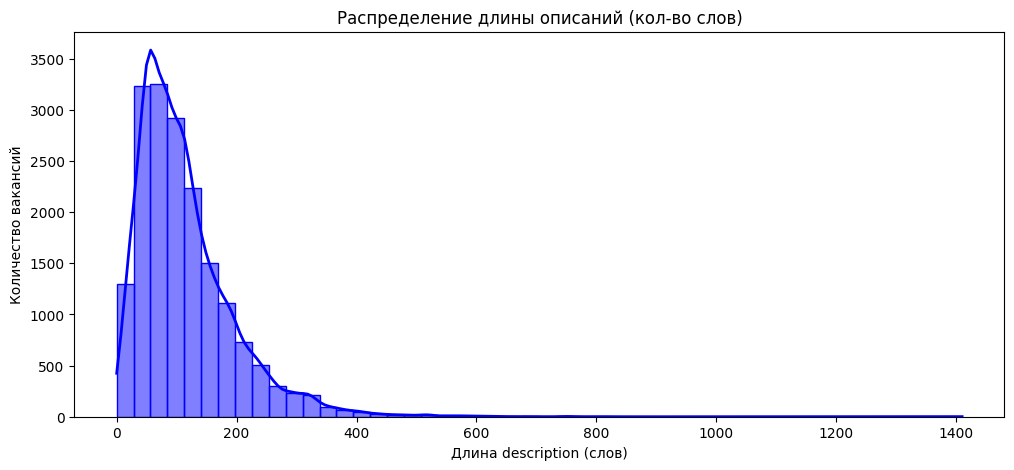

In [78]:
# 3) График распределения длины описаний
plt.figure(figsize=(12, 5))
sns.histplot(df["text_len"], bins=50, kde=True, color='blue', edgecolor='blue', line_kws={'color': 'blue', 'linewidth': 2})
plt.title("Распределение длины описаний (кол-во слов)")
plt.xlabel("Длина description (слов)")
plt.ylabel("Количество вакансий")
plt.show()


Так как распределение имеет длинный "хвост" справа и график выглядит сжатым, можно посмотреть распределение значений в лог-шкале по оси X

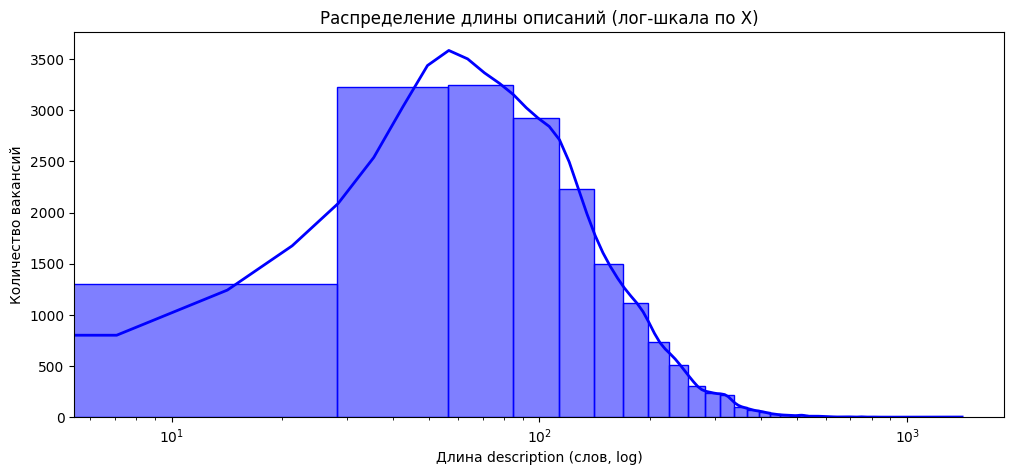

In [79]:
plt.figure(figsize=(12, 5))
sns.histplot(df["text_len"], bins=50, kde=True, color='blue', edgecolor='blue', line_kws={'color': 'blue', 'linewidth': 2})
plt.xscale("log")
plt.title("Распределение длины описаний (лог-шкала по X)")
plt.xlabel("Длина description (слов, log)")
plt.ylabel("Количество вакансий")
plt.show()


**3. Лемматизация или стемминг**

Cделаем **лемматизацию** (чаще предпочтительнее стемминга, так как она дает корректные формы слов из реального человеческого языка. Будем лемматизировать description_clean, результат положим в description_lemma.

In [80]:
# 1) Выполняем лемматизацию
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text: str) -> str:
    tokens = word_tokenize(str(text))
    lemmas = [lemmatizer.lemmatize(tok) for tok in tokens]
    return " ".join(lemmas)

df["description_lemma"] = df["description_clean"].apply(lemmatize_text)

# 2) Покажем первые 5 строк до/ после

df[["description_clean", "description_lemma"]].head(5)

,description_clean,description_lemma
0,food fast growing james beard award winning on...,food fast growing james beard award winning on...
1,organised focused vibrant awesome passion cust...,organised focused vibrant awesome passion cust...
2,client located houston actively seeking experi...,client located houston actively seeking experi...
3,company esri environmental systems research in...,company esri environmental system research ins...
4,job title itemization review managerlocation f...,job title itemization review managerlocation f...


In [81]:
# 2) Или сравним до/ после на одной строке

i = 0
print("До:\n", df.loc[i, "description_clean"][:400])
print("\nПосле:\n", df.loc[i, "description_lemma"][:400])


До:
 food fast growing james beard award winning online food community crowd sourced curated recipe hub currently interviewing full part time unpaid interns work small team editors executives developers new york city headquarters reproducing repackaging existing food content number partner sites huffington post yahoo buzzfeed various content management systemsresearching blogs websites provisions food 

После:
 food fast growing james beard award winning online food community crowd sourced curated recipe hub currently interviewing full part time unpaid intern work small team editor executive developer new york city headquarters reproducing repackaging existing food content number partner site huffington post yahoo buzzfeed various content management systemsresearching blog website provision food affiliat


**4. Финальный признак**

In [82]:
# 1) Пайплайн предобработки
def preprocess_text(text: str) -> str:
    if pd.isna(text):
        return ""

    # 1) lower + decode html entities
    text = html.unescape(str(text)).lower()

    # 2) remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text(" ")

    # 3) remove URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # 4) remove digits/punct/special: keep only a-z and spaces
    text = re.sub(r"[^a-z\s]", " ", text)

    # 5) normalize spaces
    text = re.sub(r"\s+", " ", text).strip()

    # 6) tokenize
    tokens = word_tokenize(text)

    # 7) remove stopwords + lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]

    return " ".join(tokens)

In [83]:
# 2) Формирование нового столбца
df["requirements_clean"] = df["requirements"].apply(preprocess_text)
df[["requirements", "requirements_clean"]].head(5)

,requirements,requirements_clean
0,Experience with content management systems a m...,experience content management system major plu...
1,What we expect from you:Your key responsibilit...,expect key responsibility communicate client s...
2,Implement pre-commissioning and commissioning ...,implement pre commissioning commissioning proc...
3,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",education bachelor master gi business administ...
4,QUALIFICATIONS:RN license in the State of Texa...,qualification rn license state texasdiploma ba...


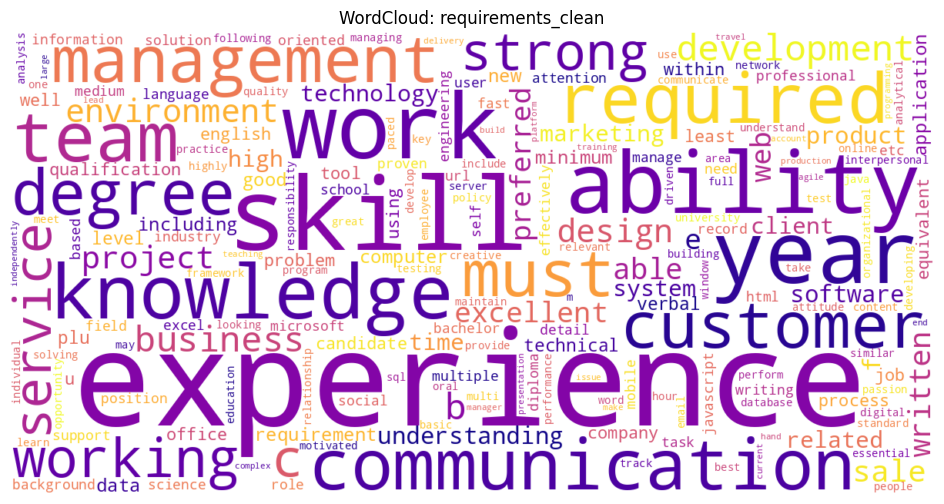

In [84]:
# 3) Облако слов

all_text = " ".join(df["requirements_clean"].dropna())

wc = WordCloud(width=1200, height=600, background_color="white", colormap="plasma", collocations=False)
wc.generate(all_text)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud: requirements_clean")
plt.show()



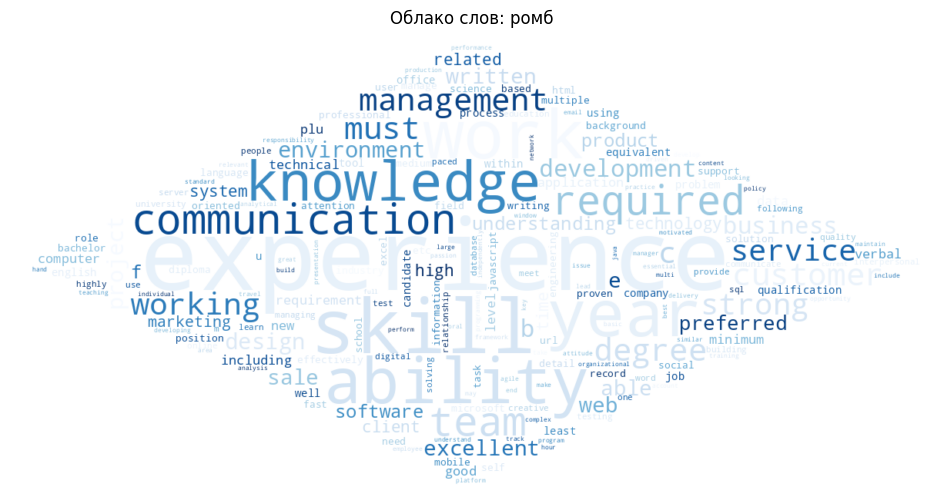

In [85]:
# 3) Облако слов в форме ромба
all_text = " ".join(df["requirements_clean"].dropna())

# размеры картинки
h, w = 600, 1200

# создаём ромб по метрике Манхэттена
Y, X = np.ogrid[:h, :w]
cy, cx = h / 2, w / 2
a, b = w * 0.50, h * 0.50  # "ширина" и "высота" ромба

rhombus = (np.abs(X - cx) / a + np.abs(Y - cy) / b) <= 1.0

# маска для WordCloud (255 - область для рисования, 0 - запрет)
mask = np.zeros((h, w), dtype=np.uint8)
mask[rhombus] = 255

wc = WordCloud(
    width=w, height=h,
    background_color="white",
    mask= 255 - mask,
    colormap="Blues",        # палитра
    collocations=False
).generate(all_text)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Облако слов: ромб")
plt.show()


**5. Модель**

In [86]:
# Выбор зависимой (y) и независимой (x) переменной, разделение выборок на обучающую (train) и тестовую (test)
TEXT_COL = "requirements_clean"
TARGET_COL = "fraudulent"

X = df[TEXT_COL].fillna("")
y = df[TARGET_COL].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Доля фейков в train:", y_train.mean().round(4), "в test:", y_test.mean().round(4))

Train: (14304,) Test: (3576,)
Доля фейков в train: 0.0484 в test: 0.0484


Данные были разделены на обучающую и тестовую выборки в соотношении 80/20. В результате получено 14304 наблюдения в обучающей выборке и 3576 - в тестовой. Параметр stratify=y обеспечил одинаковую долю целевого класса в обеих выборках: доля фейковых вакансий составила 0.0484 (примерно 4.84%) и в train, и в test. Это указывает на выраженный дисбаланс классов (фейков значительно меньше, чем реальных вакансий), поэтому при оценке качества модели важно анализировать метрики по классу 1, а не только общую accuracy.

In [87]:
# Векторизация текста и классификация
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        min_df=2
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        n_jobs=-1
    ))
])

model.fit(X_train, y_train)


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=50000, min_df=2,
                                 ngram_range=(1, 2))),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    n_jobs=-1))])

Для преобразования текстов в числовые признаки применена TF-IDF векторизация (TfidfVectorizer). В качестве классификатора использована логистическая регрессия с параметром class_weight='balanced', который компенсирует дисбаланс классов, повышая внимание модели к редкому классу (фейковые вакансии). Обучение выполнено на обучающей выборке.

              precision    recall  f1-score   support

           0     0.9817    0.9747    0.9782      3403
           1     0.5635    0.6416    0.6000       173

    accuracy                         0.9586      3576
   macro avg     0.7726    0.8082    0.7891      3576
weighted avg     0.9614    0.9586    0.9599      3576

ROC-AUC: 0.9208


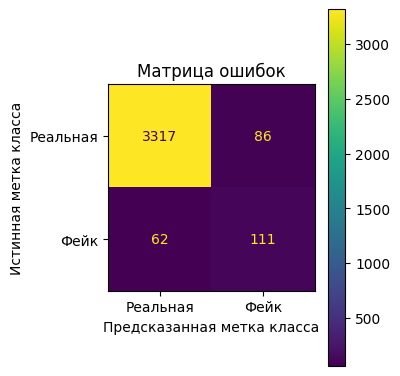

In [88]:
# 3) Оценка качества модели

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_proba).round(4))

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Реальная", "Фейк"])
disp.plot(values_format="d", ax=ax)

ax.set_title("Матрица ошибок")
ax.set_xlabel("Предсказанная метка класса")
ax.set_ylabel("Истинная метка класса")

plt.tight_layout()
plt.show()


**Интерпретация результатов и выводы**

На тестовой выборке модель показала accuracy = 0.9586, однако из-за дисбаланса классов эта метрика не является основной. Для класса 1 (фейковые вакансии) получены значения: precision = 0.5635, recall = 0.6416, F1 = 0.6000. Это означает, что среди вакансий, которые модель пометила как фейковые, примерно 56% действительно являются фейковыми (precision), а из всех реальных фейковых вакансий модель смогла обнаружить около 64% (recall). Метрика ROC-AUC = 0.9208 показывает высокую способность модели различать классы по вероятностям и подтверждает хорошее качество ранжирования вакансий по “подозрительности”.

Матрица ошибок визуализирует, сколько наблюдений каждого истинного класса модель отнесла к каждому предсказанному классу. По результатам теста модель правильно классифицировала 3317 реальных вакансий (True Negatives) и 111 фейковых вакансий (True Positives). Ошибки включают 86 ложных срабатываний (False Positives), когда реальная вакансия была помечена как фейковая, и 62 пропуска фейков (False Negatives), когда фейковая вакансия была отнесена к реальным. В контексте задачи выявления фейковых вакансий критичны именно False Negatives, так как это пропущенные мошеннические объявления.